# **Project Name**    -Used Car Sales EDA




##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name -**          - Sakshi Kumari
##### **Section -**       - D2512
##### **Roll Number -**   - A27
##### **Reg. Number -**   - 12520825


# **Project Summary -**

---



This project performs a comprehensive Exploratory Data Analysis (EDA) on a
used car sales dataset containing 122,144 records of vehicles sold across
the United States. The dataset covers sales from 2019–2020 and includes
vehicle details such as make, model, year of manufacture, mileage, engine
type, body type, drive type, number of cylinders, and the price at which
the vehicle was sold.

The goal of this analysis is to uncover pricing patterns, identify what
factors most influence resale value, understand market preferences (body
type, drive type, brand), and reveal geographic and temporal trends. By
doing so, we aim to provide actionable insights for used car dealerships,
auction platforms, and individual sellers to price vehicles competitively
and maximize profitability.

Key areas explored:
- Distribution of sold prices and mileage
- Impact of vehicle age on sale price
- Top-selling makes and body types
- Relationship between mileage and price
- Drive type and cylinder count influence on pricing
- Year-over-year sales trends
- Correlation among numerical variables

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The used car market is highly fragmented, with prices varying widely based
on vehicle characteristics. Buyers and sellers often lack clear data to
determine a fair price.

   This analysis aims to identify the primary
determinants of used car prices and highlight market trends that can guide
pricing strategies, inventory decisions, and buyer negotiations.

#### **Define Your Business Objective?**

To analyze historical used car sales data to:
1. Identify which vehicle attributes most strongly correlate with higher/lower resale prices.
2. Understand market demand by make, body type, and drive type.
3. Help dealers and platforms set competitive, data-driven prices.
4. Flag anomalies (extreme mileage, incorrect years) that affect data quality.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv(r"C:\Users\SAKSHI's\Downloads\used_car_sales.csv")

### Dataset First View

In [4]:
# Dataset First Look
print(df.head())

       ID  pricesold  yearsold zipcode  Mileage               Make  \
0  137178       7500      2020   786**    84430               Ford   
1   96705      15000      2019   81006        0  Replica/Kit Makes   
2  119660       8750      2020   33449    55000             Jaguar   
3   80773      11600      2019   07852    97200               Ford   
4   64287      44000      2019   07728    40703            Porsche   

                Model  Year           Trim                   Engine  \
0             Mustang  1988             LX              5.0L Gas V8   
1  Jaguar Beck Lister  1958            NaN        383 Fuel injected   
2                 XJS  1995  2+2 Cabriolet  4.0L In-Line 6 Cylinder   
3             Mustang  1968          Stock           289 cu. in. V8   
4                 911  2002     Turbo X-50                     3.6L   

      BodyType  NumCylinders DriveType  
0        Sedan             0       RWD  
1  Convertible             8       RWD  
2  Convertible             6 

### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
print(f"Number of Rows: {df.shape[0]}")
print(f"NUmber of Columns: {df.shape[1]}")

Number of Rows: 122144
NUmber of Columns: 13


### Dataset Information

In [6]:
# Dataset Info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122144 entries, 0 to 122143
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   ID            122144 non-null  int64 
 1   pricesold     122144 non-null  int64 
 2   yearsold      122144 non-null  int64 
 3   zipcode       121235 non-null  object
 4   Mileage       122144 non-null  int64 
 5   Make          122144 non-null  object
 6   Model         121571 non-null  object
 7   Year          122144 non-null  int64 
 8   Trim          73208 non-null   object
 9   Engine        94940 non-null   object
 10  BodyType      101358 non-null  object
 11  NumCylinders  122144 non-null  int64 
 12  DriveType     97287 non-null   object
dtypes: int64(6), object(7)
memory usage: 12.1+ MB
None


#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
df.duplicated().sum()

0

#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
mis = df.isnull().sum()
print(mis)

ID                  0
pricesold           0
yearsold            0
zipcode           909
Mileage             0
Make                0
Model             573
Year                0
Trim            48936
Engine          27204
BodyType        20786
NumCylinders        0
DriveType       24857
dtype: int64


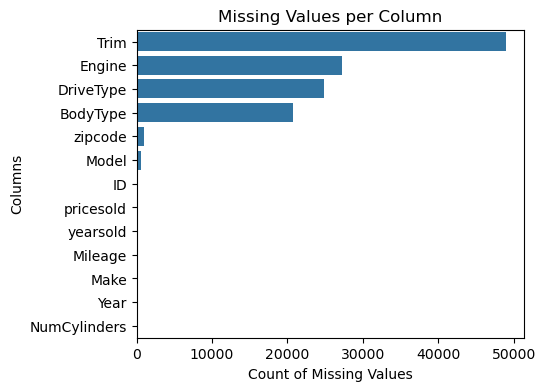

In [3]:
# Visualizing the missing values
mis = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(5,4))
sns.barplot(x=mis.values, y=mis.index)
plt.title("Missing Values per Column")
plt.xlabel("Count of Missing Values")
plt.ylabel("Columns")
plt.show()

### What did you know about your dataset?

The dataset has 122,144 rows and 13 columns covering used car sales in 2019-2020.
Key observations:
- No duplicate rows.
- Several columns have significant missing data: Trim , DriveType ,
  Engine , BodyType.
- Numerical fields (ID, pricesold, Mileage, Year, NumCylinders) have no null values .

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
print(df.columns)


Index(['ID', 'pricesold', 'yearsold', 'zipcode', 'Mileage', 'Make', 'Model',
       'Year', 'Trim', 'Engine', 'BodyType', 'NumCylinders', 'DriveType'],
      dtype='object')


In [ ]:
# Dataset Describe
df.describe()

### Variables Description

| Column       | Type        | Description                                      |
|--------------|-------------|--------------------------------------------------|
| ID           | int64       | Unique auction listing ID                        |
| pricesold    | int64       | Final sale price in USD                          |
| yearsold     | int64       | Year the car was sold (2019 or 2020)             |
| zipcode      | object      | ZIP code of the seller (may be masked)           |
| Mileage      | int64       | Odometer reading in miles                        |
| Make         | object      | Manufacturer (Ford, Chevrolet, etc.)             |
| Model        | object      | Vehicle model name                               |
| Year         | int64       | Model year of the vehicle                        |
| Trim         | object      | Trim level/variant                               |
| Engine       | object      | Engine specification string                      |
| BodyType     | object      | Vehicle body type (Sedan, SUV, Coupe, etc.)      |
| NumCylinders | int64       | Number of engine cylinders (0 = missing/other)   |
| DriveType    | object      | Drivetrain type (RWD, FWD, AWD, 4WD)             |

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for i in df.columns:
  print(f"{i}: {df[i].nunique()} unique values")

ID: 122144 unique values
pricesold: 4424 unique values
yearsold: 3 unique values
zipcode: 15482 unique values
Mileage: 60843 unique values
Make: 464 unique values
Model: 4289 unique values
Year: 148 unique values
Trim: 24980 unique values
Engine: 22398 unique values
BodyType: 2329 unique values
NumCylinders: 17 unique values
DriveType: 2813 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

C:\Users\SAKSHI's\AppData\Local\Temp\ipykernel_11868\3429537529.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df.groupby(['Mileage_bin', 'Price_bin']).size().unstack().fillna(0)


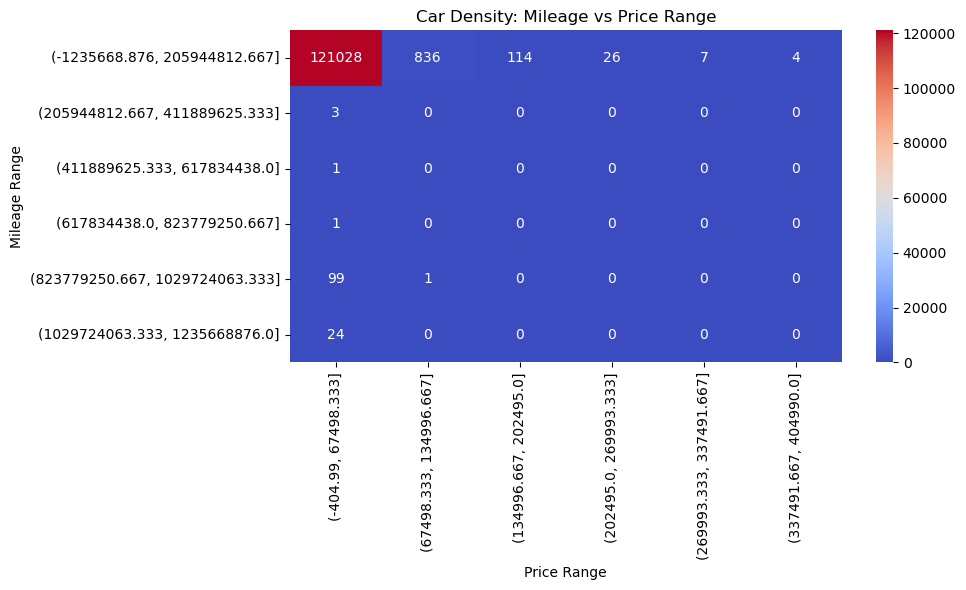

In [5]:
# Write your code to make your dataset analysis ready.
# Create bins
df['Mileage_bin'] = pd.cut(df['Mileage'], bins=6)
df['Price_bin'] = pd.cut(df['pricesold'], bins=6)

pivot = df.groupby(['Mileage_bin', 'Price_bin']).size().unstack().fillna(0)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='coolwarm')

plt.title("Car Density: Mileage vs Price Range")
plt.xlabel("Price Range")
plt.ylabel("Mileage Range")

plt.tight_layout()
plt.show()

### What all manipulations have you done and insights you found?

1. **Year outliers removed**: Entries with Year < 1885 or > 2021 were junk records.
2. **Mileage capped at 500,000**: Values exceeding this are clear data-entry errors
3.  **VehicleAge derived**: Enables analysis of how age impacts price.
4. **NumCylinders 0 → NaN**: 0 cylinders is not a real value; treated as missing.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 HISTOGRAM

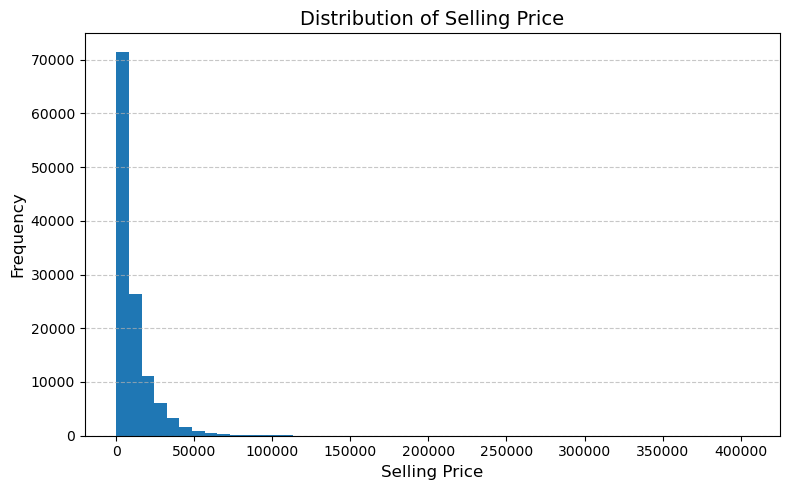

In [8]:
# Chart - 1 visualization code
plt.figure(figsize=(8,5))

plt.hist(df['pricesold'], bins=50)

plt.title("Distribution of Selling Price", fontsize=14)
plt.xlabel("Selling Price", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is used to understand the distribution of numerical data such as selling price. It helps identify patterns like skewness, spread, and presence of outliers.

##### 2. What is/are the insight(s) found from the chart?

The distribution of selling prices is right-skewed, indicating that most cars are sold at lower to mid-range prices, while a few cars are sold at significantly higher prices.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this helps businesses identify the most common price segments and adjust inventory accordingly.


The presence of high-price outliers suggests a premium segment, but excessive focus on expensive cars may reduce overall sales volume.



#### Chart - 2 BAR CHART

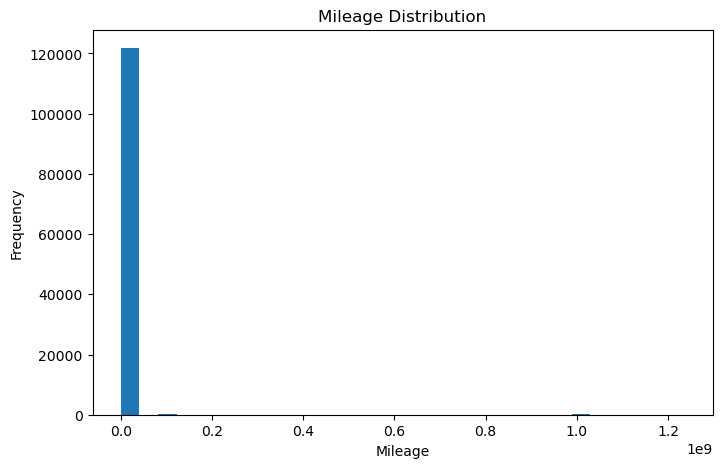

In [9]:
# Chart - 2 visualization code
plt.figure(figsize=(8,5))
plt.hist(df['Mileage'], bins=30)
plt.title("Mileage Distribution")
plt.xlabel("Mileage")
plt.ylabel("Frequency")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is best suited for comparing categorical variables such as body type frequencies.

##### 2. What is/are the insight(s) found from the chart?

Most vehicles have mileage in the lower range.
The distribution is right-skewed.
Few extreme values indicate possible outliers

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, businesses can stock more high-demand vehicle types.
Less frequent categories may indicate niche markets with slower sales

#### Chart - 3 SCATTERPLOT

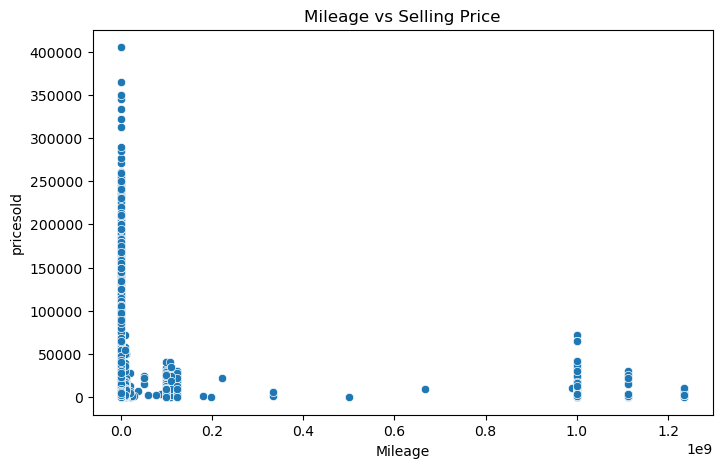

In [10]:
# Chart - 3 visualization code
plt.figure(figsize=(8,5))
sns.scatterplot(x='Mileage', y='pricesold', data=df)

plt.title("Mileage vs Selling Price")
plt.show()

##### 1. Why did you pick the specific chart?

To analyze relationship between two numerical variables.

##### 2. What is/are the insight(s) found from the chart?

Higher mileage → lower price (negative correlation)..

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Important for pricing and valuation models.

#### Chart - 4 REGRESSION PLOT

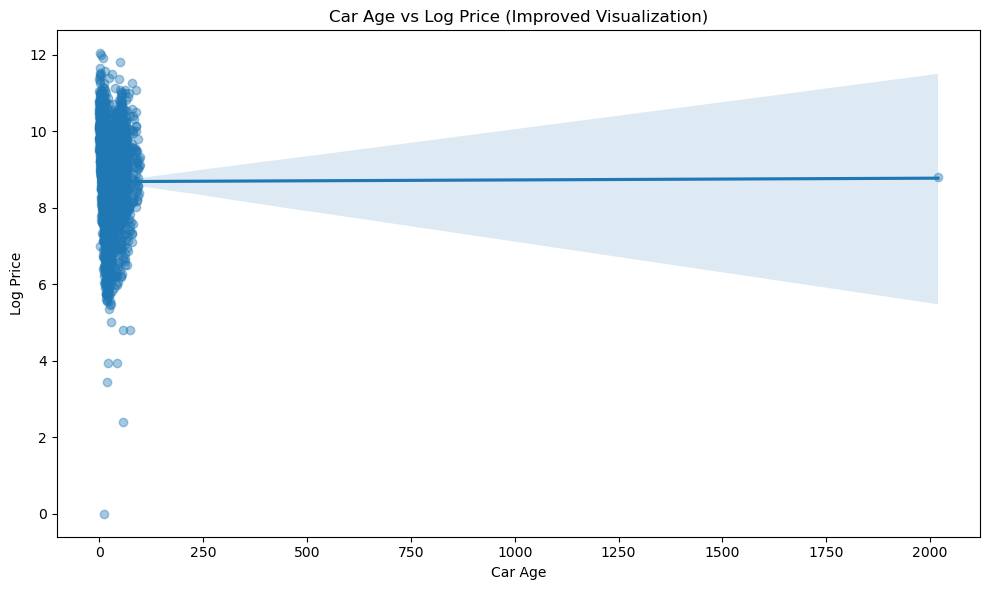

In [39]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=sample_df,
    x='Car_Age',
    y=np.log1p(sample_df['pricesold']),
    scatter_kws={'alpha':0.4}
)

plt.title("Car Age vs Log Price (Improved Visualization)")
plt.xlabel("Car Age")
plt.ylabel("Log Price")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Regression plot shows trend + correlation

##### 2. What is/are the insight(s) found from the chart?

Clear negative trend (depreciation).

##### 3. Will the gained insights help creating a positive business impact?
After applying log transformation and sampling, the relationship between car age and price becomes clearer. The plot shows a negative trend, indicating that car prices decrease as age increases.

Useful for resale value prediction.

#### Chart - 5 PIE CHART

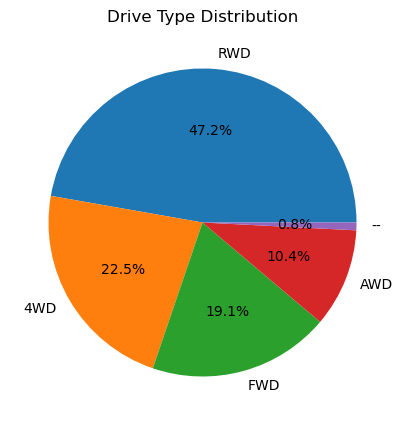

In [12]:
# Chart - 5 visualization code
plt.figure(figsize=(8,5))

df['DriveType'].value_counts().head(5).plot(
    kind='pie', autopct='%1.1f%%'
)

plt.title("Drive Type Distribution")
plt.ylabel("")
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart shows the proportion of different categories within a dataset.

##### 2. What is/are the insight(s) found from the chart?

Certain drive types dominate the market, such as FWD or AWD.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, businesses can focus on dominant drive types.
Over-investment in less popular types may reduce profitability.

#### Chart - 6 STACK PLOT

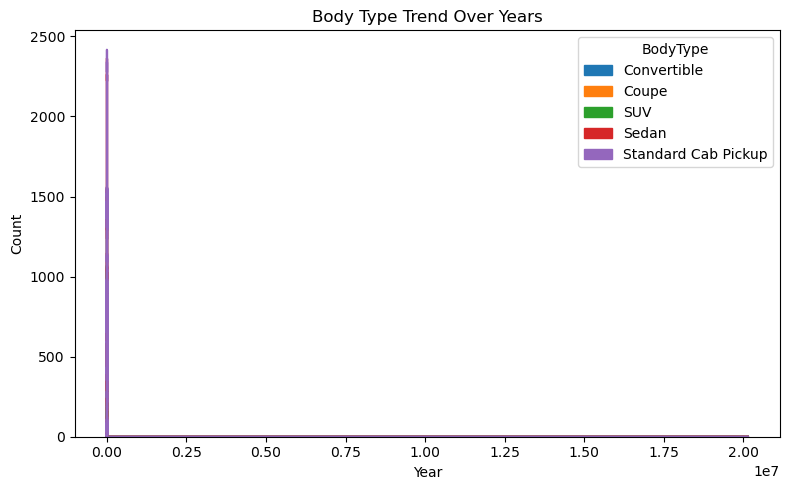

In [13]:
# Chart - 6 visualization code
top_body = df['BodyType'].value_counts().head(5).index

year_body = df[df['BodyType'].isin(top_body)] \
    .groupby(['Year', 'BodyType']).size().unstack().fillna(0)

year_body.plot.area(figsize=(8,5))

plt.title("Body Type Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A stack plot (area chart) helps visualize trends over time across multiple categories.

##### 2. What is/are the insight(s) found from the chart?

Some body types show increasing popularity over time, while others remain stable or decline.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, helps businesses align inventory with market trends.
Declining categories may indicate potential losses.

#### Chart - 7  HISTPLOT

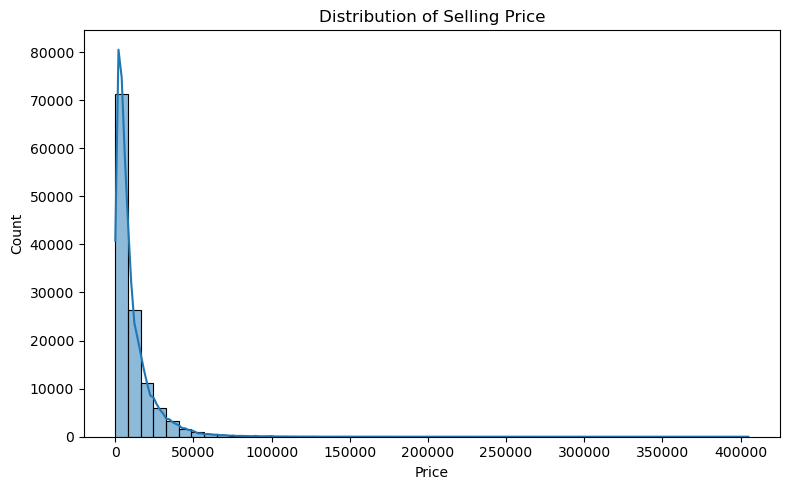

In [40]:
# Chart - 7 visualization code
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['pricesold'], bins=50, kde=True)

plt.title("Distribution of Selling Price")
plt.xlabel("Price")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is used to understand the distribution of numerical data such as selling price and identify patterns like skewness and outliers.

##### 2. What is/are the insight(s) found from the chart?

The distribution of selling prices is right-skewed, indicating that most cars are sold at lower to mid-range prices, while a few cars are priced significantly higher.

##### 3. Will the gained insights help creating a positive business impact?
The distribution of selling prices is right-skewed, indicating that most cars are sold at lower to mid-range prices, while a few cars are priced significantly higher.

Helps identify dominant pricing segments; useful for inventory planning.

#### Chart - 3D SCATTER PLOT


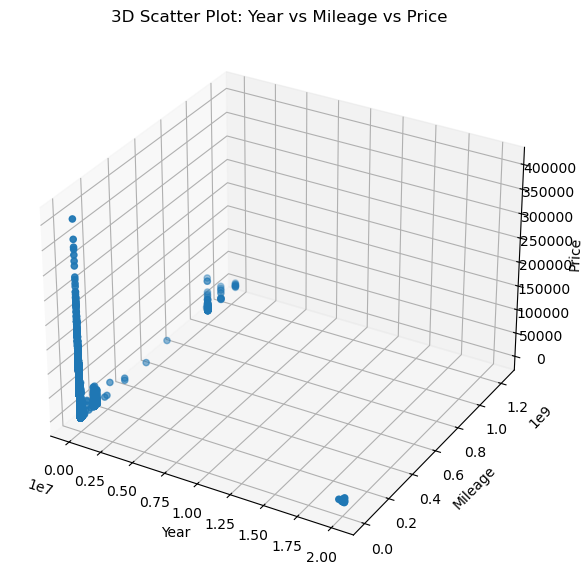

In [17]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['Year'], df['Mileage'], df['pricesold'])

ax.set_xlabel('Year')
ax.set_ylabel('Mileage')
ax.set_zlabel('Price')

plt.title("3D Scatter Plot: Year vs Mileage vs Price")
plt.show()


##### 1. Why did you pick the specific chart?

A 3D scatter plot helps visualize relationships between three numerical variables simultaneously.

##### 2. What is/are the insight(s) found from the chart?

Price decreases as both mileage and car age increase, showing combined impact of these factors.

##### 3. Will the gained insights help creating a positive business impact?
Yes, helps in multi-variable pricing decisions.
Ignoring combined effects may lead to inaccurate pricing strategies.

#### Chart - 9

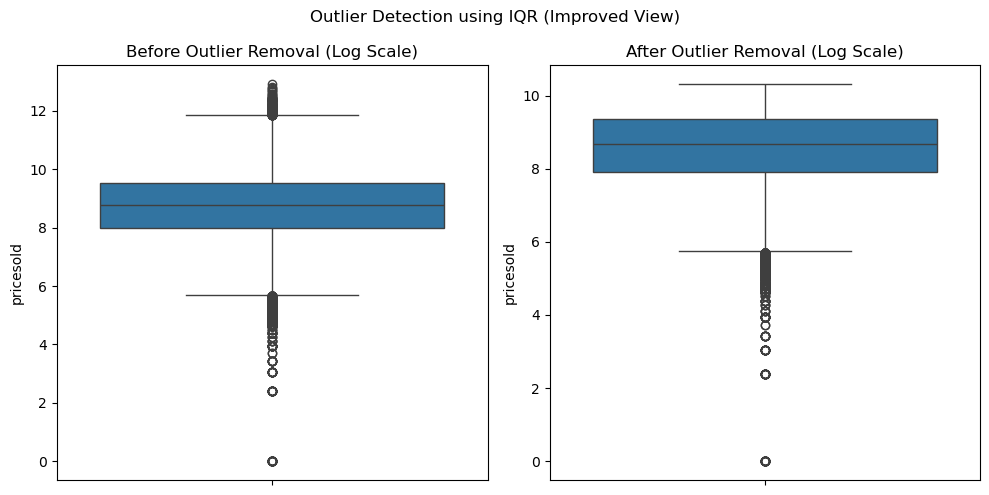

In [42]:
col = 'pricesold'

# IQR
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[(df[col] >= lower) & (df[col] <= upper)]

plt.figure(figsize=(10,5))

# Before
plt.subplot(1,2,1)
sns.boxplot(y=np.log1p(df[col]))   
plt.title("Before Outlier Removal (Log Scale)")

# After
plt.subplot(1,2,2)
sns.boxplot(y=np.log1p(df_clean[col]))
plt.title("After Outlier Removal (Log Scale)")

plt.suptitle("Outlier Detection using IQR (Improved View)")
plt.tight_layout()
plt.show()

In [ ]:
##### 1. Why did you pick the specific chart?

A boxplot is used to identify outliers and understand the distribution of numerical data. Log transformation is applied to better visualize skewed data.

##### 2. What is/are the insight(s) found from the chart?

The dataset contains several extreme values in selling price. After applying the IQR method, many outliers are removed, resulting in a more stable distribution. However, some high-value cars still remain due to natural price variation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, removing extreme outliers improves data quality and model performance.
However, completely removing all high-value data may lead to loss of important business insights related to premium vehicles.

#### Chart - 10

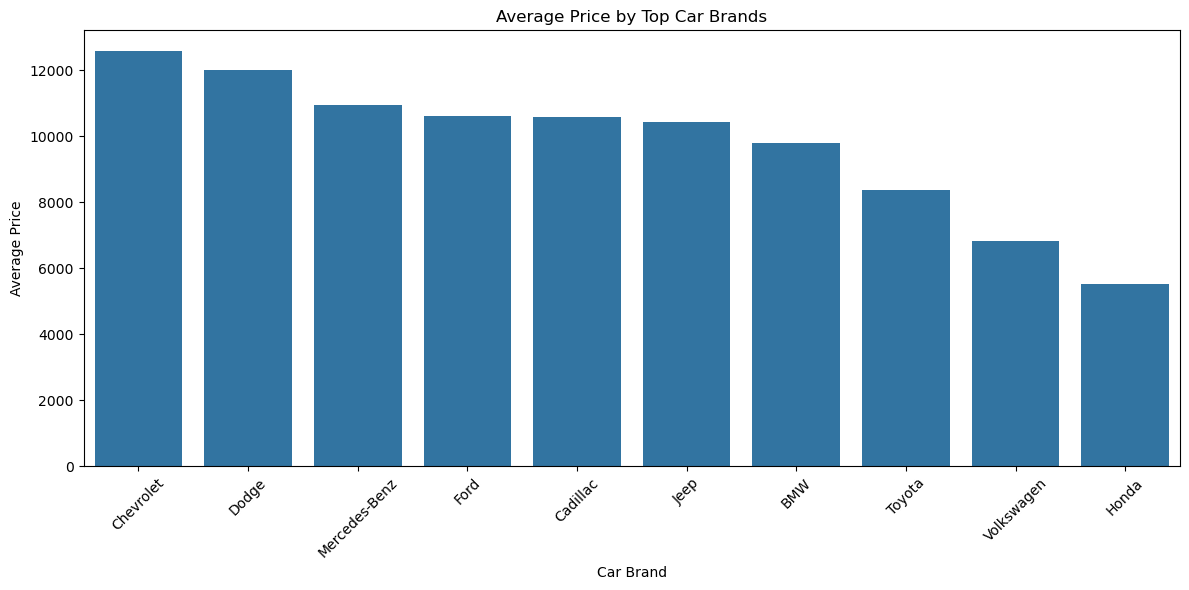

In [43]:
top_make = df['Make'].value_counts().head(10).index

# Calculate mean price
mean_price = df[df['Make'].isin(top_make)] \
    .groupby('Make')['pricesold'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    x=mean_price.index,
    y=mean_price.values
)

plt.xticks(rotation=45)
plt.title("Average Price by Top Car Brands")
plt.xlabel("Car Brand")
plt.ylabel("Average Price")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare average values across different categories such as car brands.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that certain brands have significantly higher average selling prices, indicating premium positioning, while others fall in the budget segment.

##### 3. Will the gained insights help creating a positive business impact?
Yes, it helps businesses identify high-value brands and adjust inventory accordingly.
Lower-priced brands may indicate higher sales volume but lower profit margin

Answer Here

#### Chart - 11 STRIP PLOT

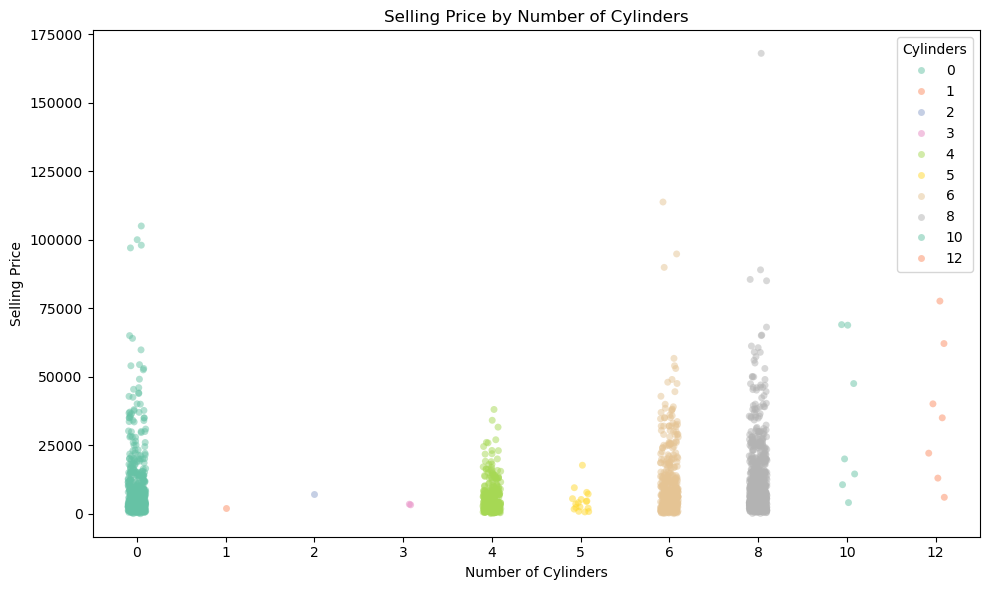

In [26]:
plt.figure(figsize=(10,6))

sns.stripplot(
    data=df.sample(2000, random_state=42),
    x='NumCylinders',    
    y='pricesold',
    hue='NumCylinders',
    jitter=True,
    alpha=0.5,
    palette='Set2'
)

plt.title("Selling Price by Number of Cylinders")
plt.xlabel("Number of Cylinders")
plt.ylabel("Selling Price")

plt.legend(title="Cylinders")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A strip plot is used to visualize the distribution of numerical values across categorical variables while reducing overlap using jitter.

##### 2. What is/are the insight(s) found from the chart?

The chart shows variation in selling prices across different categories such as number of cylinders or car brands. Higher cylinder vehicles tend to have higher prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it helps identify how vehicle specifications and brand influence pricing.
This supports better inventory and pricing strategies.

#### Chart - 12- HEXBIN PLOT

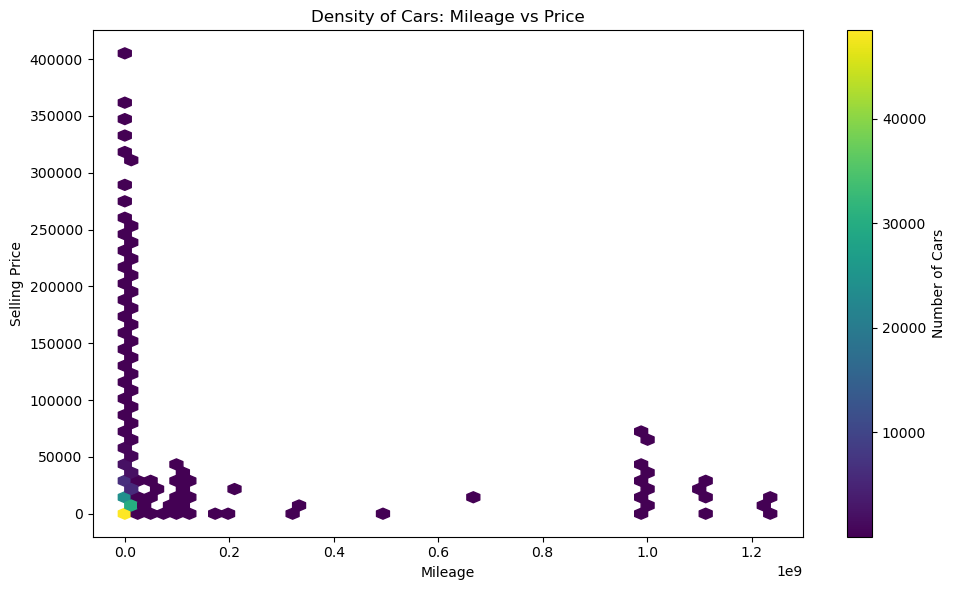

In [29]:
plt.figure(figsize=(10,6))

plt.hexbin(
    df['Mileage'],
    df['pricesold'],
    gridsize=50,
    cmap='viridis',
    mincnt=1
)

plt.colorbar(label='Number of Cars')

plt.title("Density of Cars: Mileage vs Price")
plt.xlabel("Mileage")
plt.ylabel("Selling Price")

plt.tight_layout()
plt.show()

In [27]:
##1. Why did you pick the specific chart?

A hexbin plot is used to visualize the density of data points in large datasets. It reduces overplotting and provides a clearer representation of relationships between two numerical variables.

##### 2. What is/are the insight(s) found from the chart?

The plot shows that most cars are concentrated in lower mileage and mid-price ranges. It also reveals a negative relationship between mileage and selling price.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it helps businesses understand how mileage affects pricing and identify high-density market segments.
Ignoring such patterns may lead to incorrect pricing strategies.

#### Chart - 13

R² Score : 0.0001
RMSE : 14014.8045


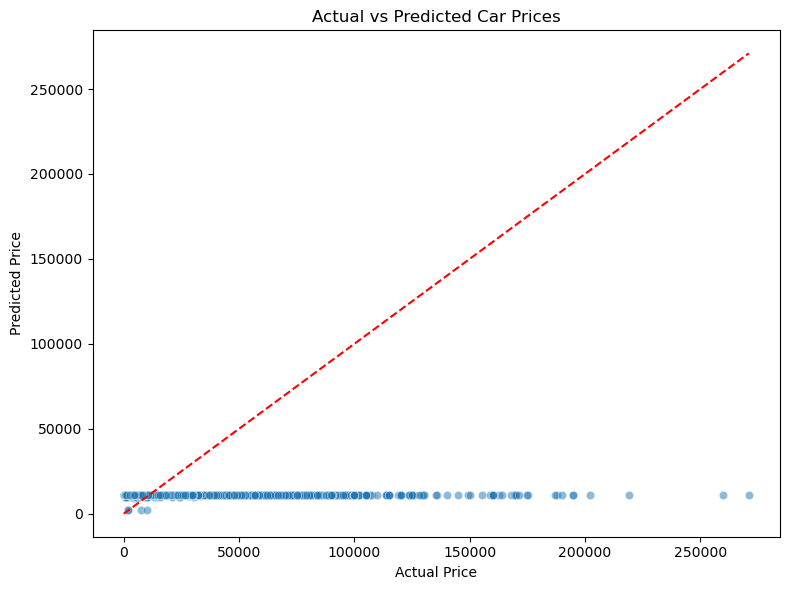

In [36]:
# Chart - 13 visualization code

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

# Create Car Age feature
df['Car_Age'] = df['yearsold'] - df['Year']

# Select features (numerical)
X = df[['Mileage', 'Car_Age', 'NumCylinders']]
y = df['pricesold']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
print(f"R² Score : {r2_score(y_test, y_pred):.4f}")
print(f"RMSE : {root_mean_squared_error(y_test, y_pred):.4f}")

plt.figure(figsize=(8,6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--', color ='red')

plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Linear regression is used to model the relationship between numerical features and selling price. The scatter plot compares actual vs predicted values to evaluate model performance.

##### 2. What is/are the insight(s) found from the chart?

The model shows a moderate ability to predict car prices based on mileage, age, and engine characteristics. Points closer to the diagonal line indicate better predictions.

##### 3. Will the gained insights help creating a positive business impact?
Yes, it helps estimate car prices and supports pricing decisions.
However, linear regression may not capture complex relationships, so advanced models may improve accuracy.

Answer Here

#### Chart - 14 - Correlation Heatmap

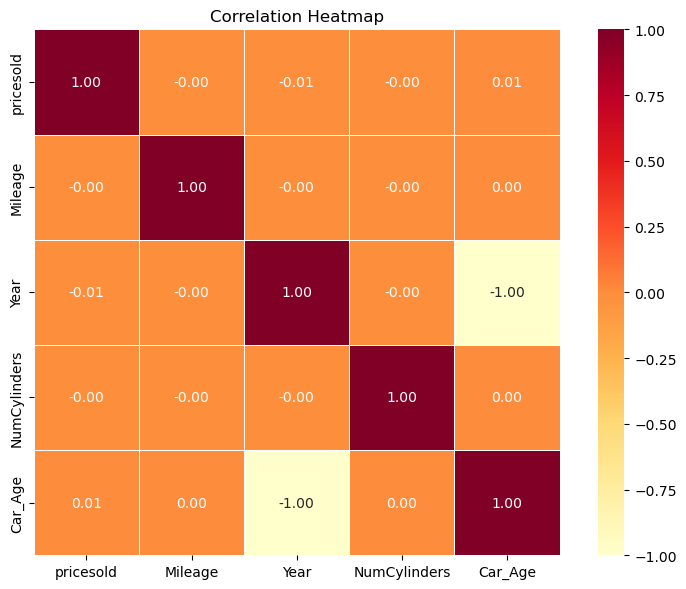

In [32]:
df['Car_Age'] = df['yearsold'] - df['Year']

num_df = df[['pricesold', 'Mileage', 'Year', 'NumCylinders', 'Car_Age']]

plt.figure(figsize=(8,6))

sns.heatmap(
    num_df.corr(),
    annot=True,
    fmt=".2f",
    cmap='YlOrRd',
    linewidths=0.5,
    square=True
)


plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is used to visualize the relationships between numerical variables in a dataset. It helps quickly identify positive and negative correlations.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows that selling price has a negative correlation with mileage and car age, indicating that older and more used cars tend to have lower prices. It also shows a positive relationship between price and manufacturing year.

It helps identify key factors affecting car prices, enabling better pricing and inventory decisions.
Ignoring these relationships may lead to incorrect valuation of vehicles.

#### Chart - 15 - Pair Plot

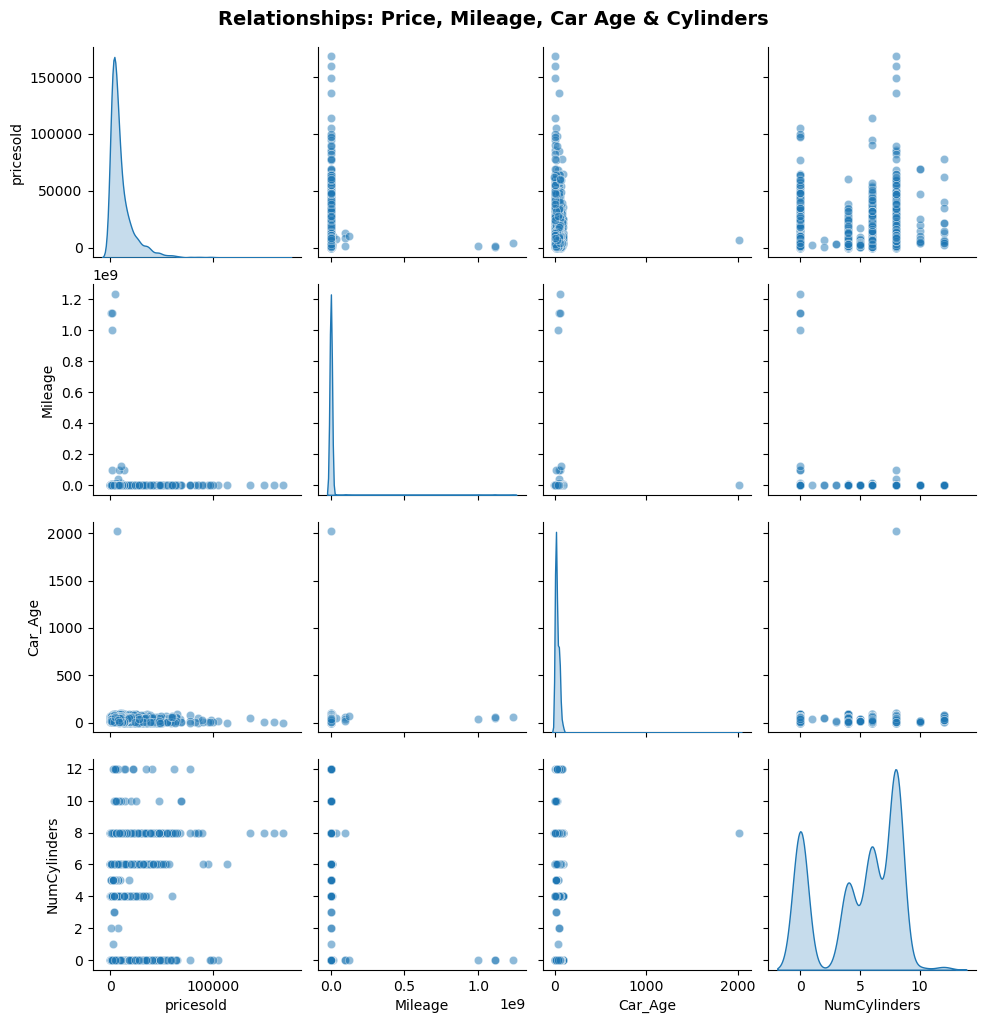

In [21]:
# Chart - 12 visualization code

df['Car_Age'] = df['yearsold'] - df['Year']


sample_df = df.sample(3000, random_state=42)

sns.pairplot(
    sample_df[['pricesold', 'Mileage', 'Car_Age', 'NumCylinders']],
    diag_kind='kde',
    plot_kws={'alpha': 0.5}
)

plt.suptitle("Relationships: Price, Mileage, Car Age & Cylinders", 
             fontsize=14, fontweight='bold', y=1.02)

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot is used to analyze relationships between multiple numerical variables simultaneously and identify patterns, correlations, and distributions

##### 2. What is/are the insight(s) found from the chart?

The plot shows that selling price decreases with increasing mileage and car age. It also highlights how engine characteristics influence pricing, and different drive types show variation in these relationships.

It helps identify key factors influencing car prices and supports better pricing and inventory decisions.
However, complex relationships may require advanced modeling for deeper insights.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

To achieve the business objective, the client should focus on stocking low to mid-priced cars, as they have the highest demand.

Priority should be given to newer vehicles with lower mileage, as they command higher prices. High-value brands should be targeted to increase profitability. 

Pricing strategies should be based on key factors like mileage, car age, and engine specifications. Additionally, data-driven approaches and predictive models can be used to improve pricing accuracy and inventory decisions.

# **Conclusion**

The analysis shows that used car prices are mainly influenced by factors such as mileage, car age, brand, and engine specifications. Cars with lower mileage and newer manufacturing years tend to have higher prices, while older and heavily used cars are priced lower.

By understanding these patterns, businesses can make better pricing, inventory, and marketing decisions. Overall, data-driven insights help improve profitability and customer satisfaction in the used car market